# Tutorial: Compare RF And Acoustic Data At One Position

This notebook shows how to:
1. load the RF and acoustic NetCDF datasets from `results/`
2. resolve one physical rover position from the RF dataset
3. recover the matching `(experiment_id, cycle_id)` pair
4. load the acoustic waveform data for that same measurement
5. plot RF CSI values and acoustic values for the selected point

The RF dataset is the source of truth for rover position. The acoustic dataset is then indexed with the matching `experiment_id` and `cycle_id`.


In [1]:
# Optional: uncomment when this Jupyter kernel misses the plotting dependencies.
import sys
!{sys.executable} -m pip install matplotlib numpy xarray pyyaml h5netcdf h5py
# Alternative NetCDF backend: !{sys.executable} -m pip install netCDF4


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

NOTEBOOK_DIR = Path.cwd().resolve()
for candidate_dir in (
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / "tutorials",
    NOTEBOOK_DIR / "processing" / "tutorials",
):
    if (candidate_dir / "csi_plot_utils.py").exists():
        NOTEBOOK_DIR = candidate_dir.resolve()
        break
else:
    raise ImportError(f"Could not locate csi_plot_utils.py from {Path.cwd().resolve()}")

UTILS_PATH = NOTEBOOK_DIR / "csi_plot_utils.py"
PROCESSING_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = PROCESSING_DIR.parent
spec = importlib.util.spec_from_file_location("csi_plot_utils", UTILS_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load utility module from {UTILS_PATH}")
csi = importlib.util.module_from_spec(spec)
sys.modules["csi_plot_utils"] = csi
spec.loader.exec_module(csi)

RESULTS_DIR = PROJECT_ROOT / "results"
ACOUSTIC_DOWNLOAD_SCRIPT = Path("processing") / "dataset-download" / "download_acoustic_datasets.py"
plt.rcParams["figure.figsize"] = (12, 4.5)


In [3]:
RF_DATASET_PATH = None
ACOUSTIC_DATASET_PATH = None

SEARCH_EXPERIMENT_IDS = None  # Example: ["EXP003", "EXP005"]. None means: search all RF experiments.
DEFAULT_EXPERIMENT_ID = "EXP003"  # Used when TARGET_POSITION is None.
SELECTED_CYCLE_ID = None  # Set an integer to override the automatic cycle selection.
TARGET_POSITION = None  # Example: {"x": 1.92, "y": 2.87, "z": None}

RF_VALUE_MODE = "power_db"  # One of: "power_db", "amplitude", "phase_deg"
ACOUSTIC_MICROPHONE_LABEL = None  # Example: "A06". None means: use the first microphone with data.
ACOUSTIC_MAX_HEATMAP_MICROPHONES = 24


In [4]:
def acoustic_download_instructions(experiment_id: str) -> str:
    script_path = ACOUSTIC_DOWNLOAD_SCRIPT.as_posix()
    return (
        f"Could not find an acoustic dataset for {experiment_id} in {RESULTS_DIR}. "
        "Expected a file such as acoustic_<EXP>.nc. "
        f"From the repo root, run `python {script_path} --experiment-id {experiment_id}` to download it into {RESULTS_DIR}, "
        f"or `python {script_path} --list` to inspect the server listing first."
    )


def resolve_acoustic_dataset_path(experiment_id: str, dataset_path: str | Path | None = None) -> Path:
    if dataset_path is not None:
        return Path(dataset_path).resolve()

    patterns = [
        f"acoustic_{experiment_id}.nc",
        f"acoustic_{experiment_id}_*.nc",
        f"acoustic_{experiment_id}*.nc",
    ]
    candidates: list[Path] = []
    for pattern in patterns:
        candidates.extend(sorted(RESULTS_DIR.glob(pattern)))
    candidates = list(dict.fromkeys(path.resolve() for path in candidates))
    if not candidates:
        raise FileNotFoundError(acoustic_download_instructions(experiment_id))
    return candidates[0]


def open_acoustic_dataset(experiment_id: str, dataset_path: str | Path | None = None) -> tuple[xr.Dataset, Path]:
    path = resolve_acoustic_dataset_path(experiment_id, dataset_path)
    ds = csi.open_netcdf_dataset(path, label=f"acoustic dataset for {experiment_id}")
    available = ds["experiment_id"].values.astype(str).tolist()
    if experiment_id not in available:
        raise ValueError(
            f"Acoustic dataset {path} does not contain experiment_id={experiment_id}. "
            f"Available experiment IDs: {available}"
        )
    return ds, path


def resolve_measurement(rf_ds: xr.Dataset) -> dict[str, object]:
    search_ids = SEARCH_EXPERIMENT_IDS
    if TARGET_POSITION is not None:
        nearest = csi.find_nearest_position_cycle(
            rf_ds,
            search_ids,
            x=TARGET_POSITION["x"],
            y=TARGET_POSITION["y"],
            z=TARGET_POSITION.get("z"),
        )
        nearest["selection_mode"] = "nearest_position"
        return nearest

    candidate_experiment_ids = (
        csi.normalize_experiment_ids(search_ids)
        if search_ids is not None
        else csi.available_experiment_ids(rf_ds)
    )
    if not candidate_experiment_ids:
        raise ValueError("No experiment_id values are available in the RF dataset.")

    selected_experiment_id = str(DEFAULT_EXPERIMENT_ID or candidate_experiment_ids[0])
    if SELECTED_CYCLE_ID is None:
        positions = csi.positions_for_experiments(rf_ds, [selected_experiment_id])
        if positions.sizes.get("measurement_index", 0) == 0:
            raise ValueError(f"No valid RF positions are available for experiment {selected_experiment_id}.")

        measurement_index = 0
        return {
            "experiment_id": str(positions["experiment_id"].values[measurement_index]),
            "cycle_id": int(positions["cycle_id"].values[measurement_index]),
            "position_available": True,
            "rover_x": float(positions["rover_x"].values[measurement_index]),
            "rover_y": float(positions["rover_y"].values[measurement_index]),
            "rover_z": float(positions["rover_z"].values[measurement_index]),
            "csi_host_count": int(positions["csi_host_count"].values[measurement_index]),
            "selection_mode": "first_valid_position",
        }

    measurement = csi.cycle_position(rf_ds, selected_experiment_id, int(SELECTED_CYCLE_ID))
    measurement["selection_mode"] = "cycle_id"
    return measurement


def extract_acoustic_cycle(acoustic_ds: xr.Dataset, experiment_id: str, cycle_id: int) -> tuple[np.ndarray, np.ndarray]:
    available_cycles = acoustic_ds["cycle_id"].values.astype(int)
    if int(cycle_id) not in available_cycles.tolist():
        raise ValueError(
            f"Acoustic dataset has no cycle_id={cycle_id} for {experiment_id}. "
            f"Available cycle count: {available_cycles.size}"
        )

    cycle = acoustic_ds.sel(experiment_id=experiment_id, cycle_id=int(cycle_id))
    microphone_labels = cycle["microphone_label"].values.astype(str)
    values = np.asarray(cycle["values"].values, dtype=float)
    if values.ndim == 1:
        values = values[np.newaxis, :]

    available_mask = np.isfinite(values).any(axis=1)
    return microphone_labels[available_mask], values[available_mask]


def select_acoustic_microphone(
    microphone_labels: np.ndarray,
    values: np.ndarray,
    microphone_label: str | None,
) -> tuple[str, np.ndarray]:
    if microphone_labels.size == 0:
        raise ValueError("No acoustic microphone waveforms are available for the selected cycle.")

    if microphone_label is None:
        index = 0
    else:
        matches = np.where(np.char.upper(microphone_labels) == str(microphone_label).upper())[0]
        if matches.size == 0:
            raise ValueError(
                f"Microphone {microphone_label!r} is not available. "
                f"Available microphones include: {microphone_labels[:10].tolist()}"
            )
        index = int(matches[0])

    return str(microphone_labels[index]), values[index]


def rf_value_series(snapshot: xr.Dataset, value_mode: str) -> tuple[str, np.ndarray]:
    mode = str(value_mode).lower()
    mapping = {
        "power_db": ("csi_power_db", snapshot["csi_power_db"].values.astype(float)),
        "amplitude": ("csi_amplitude", snapshot["csi_amplitude"].values.astype(float)),
        "phase_deg": ("csi_phase_deg", snapshot["csi_phase_deg"].values.astype(float)),
    }
    if mode not in mapping:
        raise ValueError(f"Unsupported RF_VALUE_MODE={value_mode!r}. Choose one of: {sorted(mapping)}")
    return mapping[mode]


In [5]:
rf_ds, rf_dataset_path = csi.open_dataset(experiment_id=SEARCH_EXPERIMENT_IDS, dataset_path=RF_DATASET_PATH)
measurement = resolve_measurement(rf_ds)

SELECTED_EXPERIMENT_ID = str(measurement["experiment_id"])
SELECTED_CYCLE_ID = int(measurement["cycle_id"])
acoustic_ds, acoustic_dataset_path = open_acoustic_dataset(SELECTED_EXPERIMENT_ID, ACOUSTIC_DATASET_PATH)

print(f"Loaded RF dataset: {rf_dataset_path}")
print(f"Loaded acoustic dataset: {acoustic_dataset_path}")
print(f"Selection mode: {measurement['selection_mode']}")
print(f"Resolved experiment_id: {SELECTED_EXPERIMENT_ID}")
print(f"Resolved cycle_id: {SELECTED_CYCLE_ID}")
measurement


Loaded RF dataset: C:\Users\Calle\OneDrive\Documenten\GitHub\ELLIIIT-dataset-26\results\csi_EXP003__EXP005__EXP006__EXP007__EXP008__EXP009__EXP010__EXP011__EXP012.nc
Loaded acoustic dataset: C:\Users\Calle\OneDrive\Documenten\GitHub\ELLIIIT-dataset-26\results\acoustic_EXP003.nc
Selection mode: first_valid_position
Resolved experiment_id: EXP003
Resolved cycle_id: 1


{'experiment_id': 'EXP003',
 'cycle_id': 1,
 'position_available': True,
 'rover_x': 1.9183037109375,
 'rover_y': 2.865016845703125,
 'rover_z': 0.7394267578125,
 'csi_host_count': 42,
 'selection_mode': 'first_valid_position'}

## Inspect The Selected RF Position

The grey cloud below contains the valid RF rover positions used for the search. The red star is the measurement that will also be used to index the acoustic dataset.


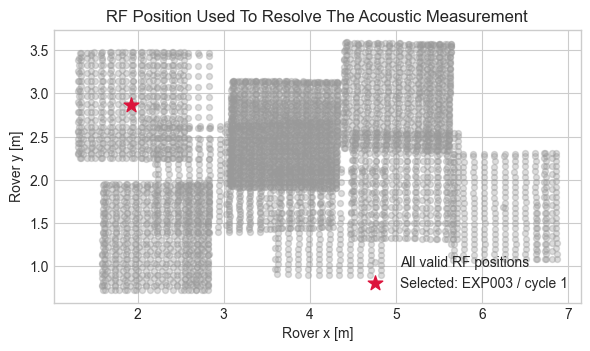

In [6]:
positions = csi.positions_for_experiments(rf_ds, SEARCH_EXPERIMENT_IDS)

fig, ax = plt.subplots(figsize=(6.8, 6.2))
ax.scatter(
    positions["rover_x"].values.astype(float),
    positions["rover_y"].values.astype(float),
    s=18,
    alpha=0.35,
    color="0.6",
    label="All valid RF positions",
)
ax.scatter(
    [float(measurement["rover_x"])],
    [float(measurement["rover_y"])],
    s=120,
    color="crimson",
    marker="*",
    label=f"Selected: {SELECTED_EXPERIMENT_ID} / cycle {SELECTED_CYCLE_ID}",
)
ax.set_aspect("equal")
ax.set_xlabel("Rover x [m]")
ax.set_ylabel("Rover y [m]")
ax.set_title("RF Position Used To Resolve The Acoustic Measurement")
ax.legend(loc="best")
plt.show()


## RF Values At The Selected Position

The RF snapshot is extracted from the CSI dataset for the resolved `(experiment_id, cycle_id)` pair.


In [7]:
antenna_positions = csi.load_antenna_positions()
rf_snapshot = csi.extract_csi_snapshot(
    rf_ds,
    SELECTED_EXPERIMENT_ID,
    SELECTED_CYCLE_ID,
    antenna_positions=antenna_positions,
)
rf_snapshot


<xarray.Dataset> Size: 3kB
Dimensions:        (hostname: 42)
Coordinates:
  * hostname       (hostname) <U3 504B 'G05' 'F05' 'E05' ... 'C10' 'B10' 'A10'
Data variables:
    csi_real       (hostname) float64 336B 0.002539 -0.002133 ... 0.003275
    csi_imag       (hostname) float64 336B 0.000818 -4.723e-05 ... 0.007729
    csi_amplitude  (hostname) float64 336B 0.002668 0.002133 ... 0.008394
    csi_power_db   (hostname) float64 336B -51.48 -53.42 ... -52.43 -41.52
    csi_phase_deg  (hostname) float64 336B 17.86 -178.7 -69.94 ... -105.5 67.04
    antenna_x      (hostname) float64 336B 0.35 1.55 2.75 ... 5.15 6.35 7.55
    antenna_y      (hostname) float64 336B 0.66 0.66 0.66 ... 3.66 3.66 3.66
    antenna_z      (hostname) float64 336B 2.4 2.4 2.4 2.4 ... 2.4 2.4 2.4 2.4
Attributes:
    experiment_id:       EXP003
    cycle_id:            1
    position_available:  True
    rover_x:             1.9183037109375
    rover_y:             2.865016845703125
    rover_z:             0.7394267578125
    csi_host_count:      42

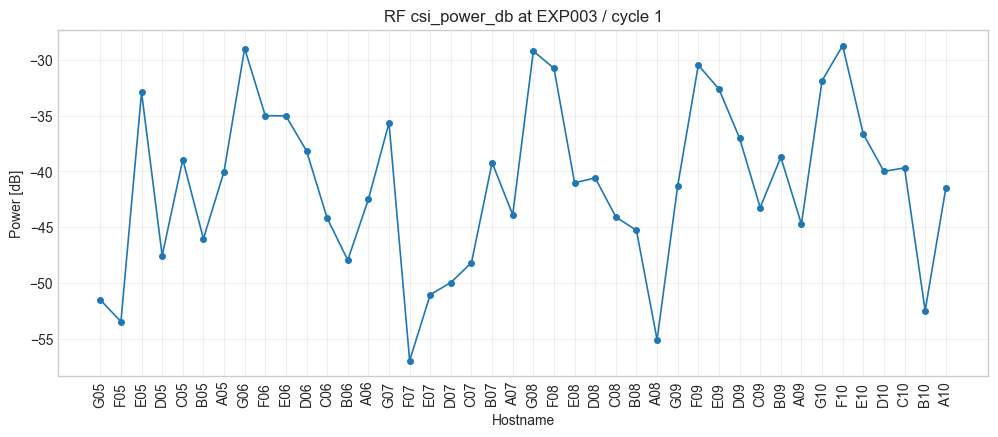

In [8]:
rf_variable_name, rf_values = rf_value_series(rf_snapshot, RF_VALUE_MODE)
hostnames = rf_snapshot["hostname"].values.astype(str)
ylabel_map = {
    "csi_power_db": "Power [dB]",
    "csi_amplitude": "Amplitude",
    "csi_phase_deg": "Phase [deg]",
}

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(hostnames, rf_values, marker="o", linewidth=1.2, markersize=4)
ax.set_xlabel("Hostname")
ax.set_ylabel(ylabel_map[rf_variable_name])
ax.set_title(
    f"RF {rf_variable_name} at {SELECTED_EXPERIMENT_ID} / cycle {SELECTED_CYCLE_ID}"
)
ax.grid(True, alpha=0.3)
ax.tick_params(axis="x", rotation=90)
plt.show()


## Matching Acoustic Values

The acoustic dataset is opened for the resolved experiment and then indexed with the same `cycle_id`.


In [9]:
acoustic_microphone_labels, acoustic_values = extract_acoustic_cycle(
    acoustic_ds,
    SELECTED_EXPERIMENT_ID,
    SELECTED_CYCLE_ID,
)
selected_microphone_label, selected_waveform = select_acoustic_microphone(
    acoustic_microphone_labels,
    acoustic_values,
    ACOUSTIC_MICROPHONE_LABEL,
)

print(f"Acoustic microphones with data: {acoustic_microphone_labels.size}")
print(f"Selected microphone for the waveform plot: {selected_microphone_label}")
print(f"Samples per waveform: {acoustic_values.shape[1]}")
acoustic_microphone_labels[:min(10, acoustic_microphone_labels.size)]


Acoustic microphones with data: 91
Selected microphone for the waveform plot: A06
Samples per waveform: 14999


array(['A06', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'B01',
       'B02'], dtype='<U3')

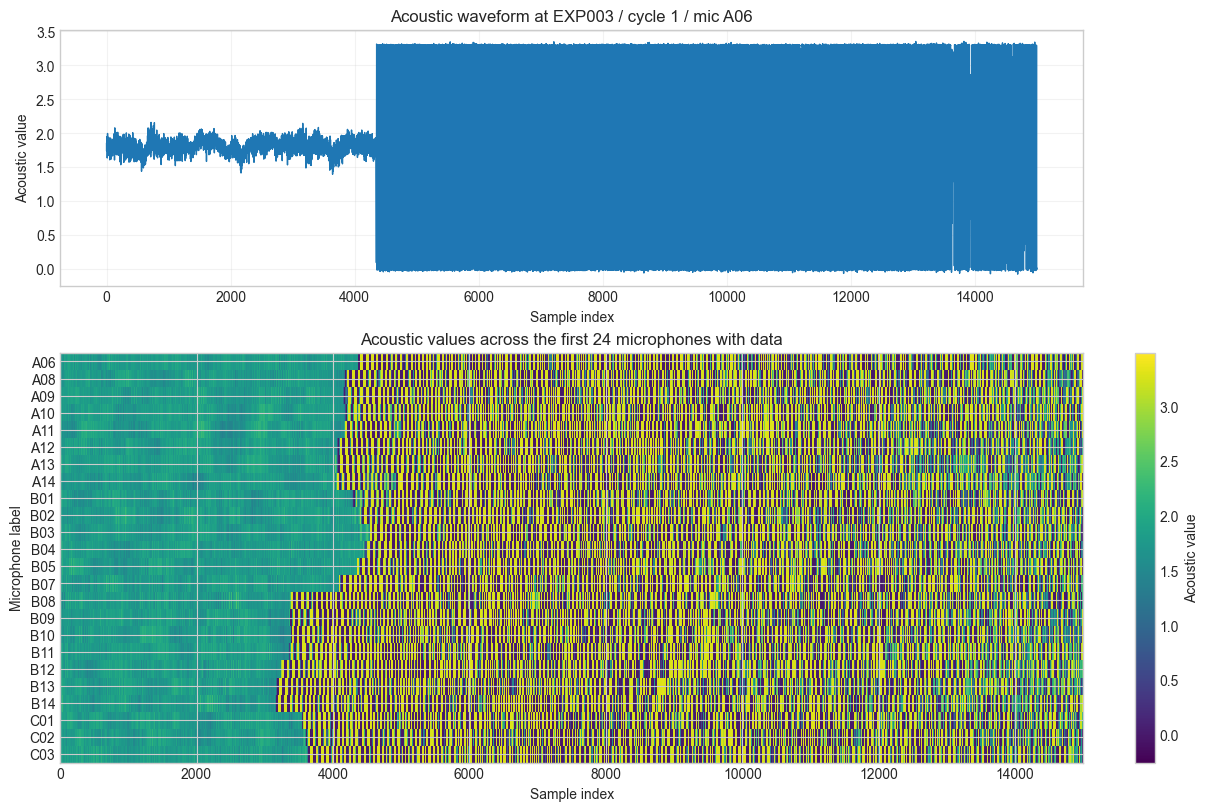

In [10]:
heatmap_count = min(ACOUSTIC_MAX_HEATMAP_MICROPHONES, acoustic_microphone_labels.size)
heatmap_labels = acoustic_microphone_labels[:heatmap_count]
heatmap_values = acoustic_values[:heatmap_count]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True, height_ratios=[1.0, 1.6])

axes[0].plot(np.arange(selected_waveform.size), selected_waveform, linewidth=1.0)
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Acoustic value")
axes[0].set_title(
    f"Acoustic waveform at {SELECTED_EXPERIMENT_ID} / cycle {SELECTED_CYCLE_ID} / mic {selected_microphone_label}"
)
axes[0].grid(True, alpha=0.25)

image = axes[1].imshow(heatmap_values, aspect="auto", interpolation="none", cmap="viridis")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Microphone label")
axes[1].set_title(f"Acoustic values across the first {heatmap_count} microphones with data")
axes[1].set_yticks(np.arange(heatmap_count))
axes[1].set_yticklabels(heatmap_labels.tolist())
fig.colorbar(image, ax=axes[1], label="Acoustic value")

plt.show()
